# iprPy thermal_conductivity_green_kubo calculation

In [1]:
# Standard library imports
import datetime
from copy import deepcopy

# http://www.numpy.org/
import numpy as np

# https://ipython.org/
from IPython.display import display, Code, Markdown, Pretty, Image

import matplotlib.pyplot as plt

# https://github.com/usnistgov/atomman
import atomman as am
import atomman.unitconvert as uc

# https://github.com/usnistgov/iprPy
import iprPy

print('Notebook last executed on', datetime.date.today(), 'using iprPy version', iprPy.__version__)

Notebook last executed on 2026-06-26 using iprPy version 0.12.a


## 1. Load calculation and view description

### 1.1. Load the calculation

In [2]:
# Load the calculation being demoed
calculation = iprPy.load_calculation('thermal_conductivity_green_kubo')

### 1.2. Display calculation description and theory

In [3]:
# Display main docs and theory
display(Markdown(calculation.maindoc))
display(Markdown(calculation.theorydoc))

# thermal_conductivity_green_kubo calculation style

**Lucas M. Hale**, [lucas.hale@nist.gov](mailto:lucas.hale@nist.gov?Subject=ipr-demo), *Materials Science and Engineering Division, NIST*.

## Introduction

The thermal_conductivity_green_kubo calculation style evaluates the thermal conductivity of a system at equilibrium using the Green-Kubo method.

### Version notes

- v0.12.0: Calculation added.
  
### Additional dependencies

### Disclaimers

- [NIST disclaimers](http://www.nist.gov/public_affairs/disclaimer.cfm)
- This calculation can only capture the classical non-electronic component of thermal conductivity. It is best suited for non-conductive materials at temperatures above their Debye temperatures.
- Convergence of the autocorrelation function to zero at large time deltas is sensitive to the material, potential and temperature.  Always check the computed autocorrelation function!


## Theory

This calculation uses the LAMMPS compute heat/flux command to estimate the thermal conductivity of a system using the equilibrium Green-Kubo method.

The compute heat/flux command computes the heat flux $J$ using the equation

$$ \mathbf{J} = \frac{1}{V} \left[ \sum_i{e_i v_i} - \sum_i{S_i v_i}\right], $$

where $e_i$ is the per-atom energy (potential and kinetic), $v_i$ is the per-atom velocity, and $S_i$ is the per-atom stress tensor.

The command allows for the specification of computes for the per-atom kinetic energies, potential energies, and stress tensors. The kinetic and potential energies are usually the normal values computed for a potential, while the stress tensors can be computed with either "compute stress/atom" or "compute centroid/stress/atom".  The documentation states that normally only the virial component of the stress (and not the kinetic component) should be used. As for the two alternate stress computes, the LAMMPS documentation states that compute centroid/stress/atom should be used for angle, dihedral, improper and constraint force contributions as the regular compute stress/atom produces unphysical heat/flux values.

The thermal conductivity $\kappa$ can then be computed from the auto-correlation of the heat capacity

$$ \kappa = \frac{V}{k_BT^2} \int_0^{\infty}{\left< J_x\left( 0 \right) J_x\left( t \right)\right>dt} = \frac{V}{3k_BT^2} \int_0^{\infty}{\left< \mathbf{J}\left( 0 \right) \cdot \mathbf{J}\left( t \right)\right>dt}$$

The auto-correlation integrals can be estimated by numerically integrating from the measured heat flux values.

## 2. Display the underlying code

This section displays the underlying code used when calculation.calc() is called in Section 4. It is provided here allowing any users to see and understand how the calculation works.

Feel free to modify and test the functions for yourself!  You can do this by
1. Copy the Python code displayed here into a "Code" cell and run it.
2. In Section 2.2, set "savefiles = True" and run the cell to save any supporting non-python files to the working directory.
3. In Section 4, call the primary calculation function directly rather than using calculation.calc().

### 2.1. Show code and supporting file names and content

In [4]:
# Display calculation code and supporting files
for filename, contents in calculation.files.items():
    display(Markdown(f'## Contents of file "{filename}"'))
    if filename[-3:] == '.py':
        display(Code(contents, language='python'))
    else:
        display(Pretty(contents))

## Contents of file "thermal_conductivity_green_kubo.py"

# Python script created by Lucas Hale

# Standard library imports
from typing import Optional, Union

# http://www.numpy.org/
import numpy as np

import matplotlib.pyplot as plt

# https://github.com/usnistgov/atomman 
import atomman as am
import atomman.unitconvert as uc
from atomman.typing import lammpspotential, unitfloat
from atomman.lammps import LAMMPS, LAMMPSobj

def thermal_conductivity_green_kubo(lammps_command: Union[str, LAMMPSobj],
                                    system: am.System,
                                    potential: lammpspotential,
                                    temperature: float,
                                    mpi_command: Optional[str] = None,
                                    timestep: Optional[unitfloat] = None,
                                    equilsteps: int = 0,
                                    runsteps: int = 500000,
                                    centroid_stress: bool = False,
                                    createvelocities: bool = False,
                                    randomseed: Optional[int] = None,
                                    usefiles: bool = False) -> dict:
    """
    Computes the thermal conductivity of a system using the equilibrium
    Green-Kubo method.

    Parameters
    ----------
    lammps_command : str, LAMMPSEXE or LAMMPSLIB
        LAMMPS executable command, LAMMPS library name, or an atomman LAMMPS
        interface object.
    system : atomman.System
        The system to perform the calculation on.
    potential : atomman.lammps.Potential
        The LAMMPS implemented potential to use.
    temperature : float
        The temperature to run at.
    mpi_command : str, optional
        The MPI command for running LAMMPS in parallel. If not given, LAMMPS
        will run serially.
    timestep : float, optional
        The amount of time to increase each frame of the simulation. The 
        default value is given by the default value for the specified LAMMPS
        unit system. 
    equilsteps : int, optional
        How many timesteps the equilibration simulation will run for.  Default 
        value is 0.
    runsteps : int, optional
        How many timesteps the simulation will run for. Default value is 500,000.
    centroid_stress : bool, optional
        Changes which LAMMPS compute method is used for estimating the per-atom
        stress values: False (default) uses stress/atom, while True uses 
        centroid/stress/atom.
    createvelocities : bool, optional
        Setting this to True will assign new random velocities to the atoms
        prior to running.  If this is used, then it would be wise to set an
        equilsteps value to let the velocities equilibrate before running the
        main Green-Kubo run.
    randomseed : int or None, optional
        Random number seed used by LAMMPS in creating velocities.  Only used
        if resetvelocities is True.  Default is None which will select a
        random int between 1 and 900000000.
    usefiles : bool, optional
        If set to True, then all input/output files for LAMMPS will be generated.
        Default value of False will minimize the files created.
    
    Returns
    -------
    dict
        Dictionary of results consisting of keys:

        -**'viscosity_xy'** (*float*) - The calculated viscosity using only the
        Pxy pressures.
        -**'viscosity_xz'** (*float*) - The calculated viscosity using only the
        Pxz pressures.
        -**'viscosity_yz'** (*float*) - The calculated viscosity using only the
        Pyz pressures.
        -**'viscosity'** (*float*) - The calculated viscosity using all three
        shear pressures.
    ----------
    """

    # Create a LAMMPS object if needed
    lmp = LAMMPS(lammps_command, mpi_command=mpi_command, potential=potential)

    logfile = 'log.lammps'
    if usefiles or not lmp.islib:
        script = 'kappaGK.in'
    else:
        script = None

    # Check/select a randomseed value
    randomsee

### 2.2. Optional: Save supporting files

Set "savefiles = True" to save files locally.  

Note that the code above should be using atomman.tools.read_calc_file() to read the files, which will read any local files with matching names if they exist or read the packaged version if the local files do not exist. This means that if you save the files locally, you can modify them and see how it affects the calculation!

In [5]:
savefiles = False

if savefiles:
    for filename, contents in calculation.files.items():
        if filename[-3:] != '.py':
            with open(filename, 'w') as f:
                f.write(contents)

## 3. Specify input parameters

### 3.1. System-specific paths

- __lammps_command__ is the LAMMPS command to use (required).
- __mpi_command__ MPI command for running LAMMPS in parallel. A value of None will run simulations serially.

In [6]:
lammps_command = 'lmp_serial'
mpi_command = None
mpi_command = 'mpiexec -localonly 6'

# Optional: check that LAMMPS works and show its version 
print(f'LAMMPS version = {am.lammps.checkversion(lammps_command)["version"]}')

LAMMPS version = 3 Mar 2020


### 3.2. Interatomic potential

- __potential_name__ gives the name of a potential_LAMMPS record to find and download from the iprPy library.  
- __potential__ is a potential_LAMMPS or potential_LAMMPS_KIM record object (required).

See documentation for the [potentials package](https://github.com/usnistgov/potentials/tree/master/doc) for more options on finding, loading and building potential objects (doc Notebook #s 0, 5.3, 5.4 and 7).

In [7]:
potential_name = '1985--Stillinger-F-H--Si--LAMMPS--ipr1'

# Retrieve potential and parameter file(s) using atomman
potential = am.load_lammps_potential(id=potential_name, getfiles=True)

### 3.3. Initial unit cell system

- __ucell__ is an atomman.System representing a fundamental unit cell of the system (required).  Here, this is generated by loading the relaxed fcc crystal for the potential from the database.

See documentation for the [atomman package](https://github.com/lmhale99/atomman/tree/master/doc/tutorial) for more options on building and loading atomic configurations (doc Notebook #s 1.1, 1.2, 1.3, 1.4 and 1.4.*)

In [8]:
# Create ucell by loading prototype record
ucell = am.load('prototype', 'A4--C--dc', symbols='Si', a=5.445)

print(ucell)

avect =  [ 5.445,  0.000,  0.000]
bvect =  [ 0.000,  5.445,  0.000]
cvect =  [ 0.000,  0.000,  5.445]
origin = [ 0.000,  0.000,  0.000]
natoms = 8
natypes = 1
symbols = ('Si',)
pbc = [ True  True  True]
per-atom properties = ['atype', 'pos']
     id |   atype |  pos[0] |  pos[1] |  pos[2]
      0 |       1 |   0.000 |   0.000 |   0.000
      1 |       1 |   2.723 |   2.723 |   0.000
      2 |       1 |   2.723 |   0.000 |   2.723
      3 |       1 |   0.000 |   2.723 |   2.723
      4 |       1 |   1.361 |   1.361 |   1.361
      5 |       1 |   1.361 |   4.084 |   4.084
      6 |       1 |   4.084 |   1.361 |   4.084
      7 |       1 |   4.084 |   4.084 |   1.361


### 3.4. System modifications

- __sizemults__ list of three integers specifying how many times the ucell vectors of $a$, $b$ and $c$ are replicated in creating system.
- __system__ is an atomman.System to perform the scan on (required). 

In [9]:
sizemults = [10, 10, 10]

# Generate system by supersizing ucell
system = ucell.supersize(*sizemults)
print('# of atoms in system =', system.natoms)

# of atoms in system = 8000


### 3.5 Calculation-specific parameters

- __temperature__ (*float*) The temperature to run at.
- __timestep__ (*float or None, optional*) The amount of time to increase each frame of the simulation. If None (default), the timestep will be set to the default LAMMPS value for the specified LAMMPS unit system.
- __equilsteps__ (*int, optional*) How many timesteps the equilibration simulation will run for.  Default value is 0.
- __runsteps__ (*int, optional*) How many timesteps the simulation will run for. Default value is 500,000.
- __centroid_stress__ (*bool, optional*) Changes which LAMMPS compute method is used for estimating the per-atom stress values: False (default) uses stress/atom, while True uses centroid/stress/atom.
- __createvelocities__ (*bool, optional*) Setting this to True will assign new random velocities to the atoms prior to running.  If this is used, then it would be wise to set an equilsteps value to let the velocities equilibrate before running the main Green-Kubo run.
- __randomseed__ (*int or None, optional*) Random number seed used by LAMMPS in creating velocities.  Only used if resetvelocities is True.  Default is None which will select a random int between 1 and 900000000.

In [10]:
equilsteps = 100000
temperature = 1000
runsteps = 1000000
centroid_stress = False
createvelocities = True
timestep = None
randomseed = None

## 4. Run calculation and view results

### 4.1. Run calculation

All primary calculation method functions take a series of inputs and return a dictionary of outputs.

In [11]:
# What is calculation.calc an alias of?
calculation.calc.__module__

'iprPy.calculation.thermal_conductivity_green_kubo.thermal_conductivity_green_kubo'

In [12]:
results_dict = calculation.calc(lammps_command, system, potential, temperature,
                                mpi_command = mpi_command,
                                timestep = timestep,
                                equilsteps = equilsteps,
                                runsteps = runsteps,
                                centroid_stress = centroid_stress,
                                createvelocities = createvelocities,
                                randomseed = randomseed)
print(results_dict.keys())

dict_keys(['gkx', 'gky', 'gkz', 'kappax', 'kappay', 'kappaz', 'kappa'])


### 4.2. Report results

Values returned in the results_dict:

- **'gkx'** (*atomman.thermo.GreenKuboKappa*) - The Green-Kubo solver containing the Jx values.  Useful for further analysis.
- **'gky'** (*atomman.thermo.GreenKuboKappa*) - The Green-Kubo solver containing the Jy values.  Useful for further analysis.
- **'gkz'** (*atomman.thermo.GreenKuboKappa*) - The Green-Kubo solver containing the Jz values.  Useful for further analysis.
- **'kappax'** (*float*) - The estimated thermal conductivity in the x direction.
- **'kappay'** (*float*) - The estimated thermal conductivity in the y direction.
- **'kappaz'** (*float*) - The estimated thermal conductivity in the z direction.
- **'kappa'** (*float*) - The averaged bulk thermal conductivity.

In [13]:
kappa_units = 'W/(m*K)'

print(f'κx = {uc.get_in_units(results_dict['kappax'], kappa_units)} {kappa_units}') 
print(f'κy = {uc.get_in_units(results_dict['kappay'], kappa_units)} {kappa_units}') 
print(f'κz = {uc.get_in_units(results_dict['kappaz'], kappa_units)} {kappa_units}') 
print(f'κ =  {uc.get_in_units(results_dict['kappa'], kappa_units)} {kappa_units}') 

κx = 41.21766382963405 W/(m*K)
κy = 46.01597967018068 W/(m*K)
κz = 44.97474396255558 W/(m*K)
κ =  44.06946248745676 W/(m*K)


Additionally, the calculation will generate a plot of the autocorrelation functions for the three directions out to the identified cutoff (which should roughly correspond to when the ACF approaches zero).

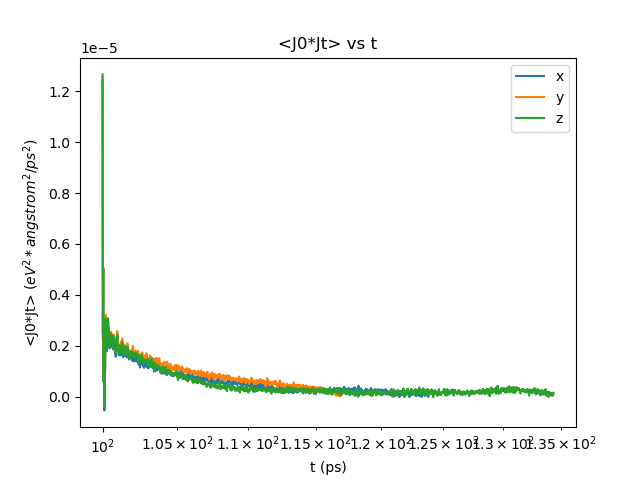

In [14]:
Image('J0Jt.png')

With the Green-Kubo solvers, you can do further analysis of the calculation, such as check the identified cutoff and play around with how sensitive kappa estimates are to the cutoff.

In [15]:
gkx = results_dict['gkx']
gky = results_dict['gky']
gkz = results_dict['gkz']

In [16]:
print(gkx.index_cut, gky.index_cut, gkz.index_cut)

23919 16849 34361


Text(0, 0.5, 'cutoff index')

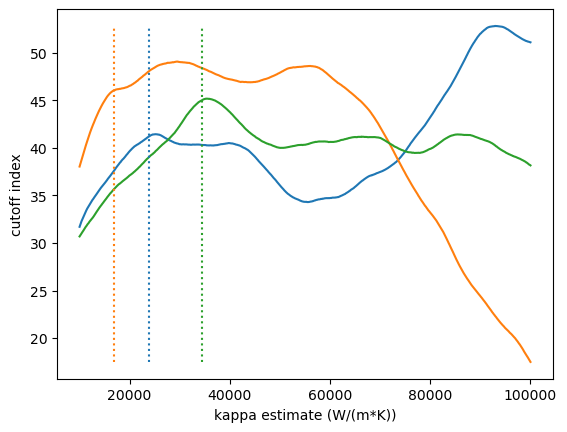

In [22]:
kapxs = []
kapys = []
kapzs = []

cutoffs = [i for i in range(10000, 100001)]
for i in cutoffs:
    kapxs.append(gkx.kappa(index_cut=i))
    kapys.append(gky.kappa(index_cut=i))
    kapzs.append(gkz.kappa(index_cut=i))
    
plt.plot(cutoffs, uc.get_in_units(kapxs, kappa_units), 'C0')
plt.plot(cutoffs, uc.get_in_units(kapys, kappa_units), 'C1')
plt.plot(cutoffs, uc.get_in_units(kapzs, kappa_units), 'C2')

ymin = uc.get_in_units(np.min([kapxs, kapys, kapzs]), kappa_units)
ymax = uc.get_in_units(np.max([kapxs, kapys, kapzs]), kappa_units)

plt.plot([gkx.index_cut, gkx.index_cut], [ymin, ymax], 'C0:')
plt.plot([gky.index_cut, gky.index_cut], [ymin, ymax], 'C1:')
plt.plot([gkz.index_cut, gkz.index_cut], [ymin, ymax], 'C2:')

plt.xlabel(f'kappa estimate ({kappa_units})')
plt.ylabel(f'cutoff index')

### 4.3. Optional: Clean calculation files

The calculation may generate output files when it runs.  Calling calculation.clean_files() will delete any generated files to keep the workspace clean.

In [18]:
#calculation.clean_files()